In [1]:
from matplotlib import pyplot as plt

from jax import config
config.update("jax_enable_x64", True)

import jax.random as jr
import jax.numpy as jnp
np = jnp
from random_paths import (integrated_ou_first_on_path, path_to_increments,
                                          random_trigonometric_polynomial_paths)
key = jr.PRNGKey(123)

X = integrated_ou_first_on_path(
    key,
    batch=3,
    steps=160,
    dim=2,
    trunc=3,
    volatility=5.0,
    mean_reversion=5.0
)

dX = path_to_increments(X)

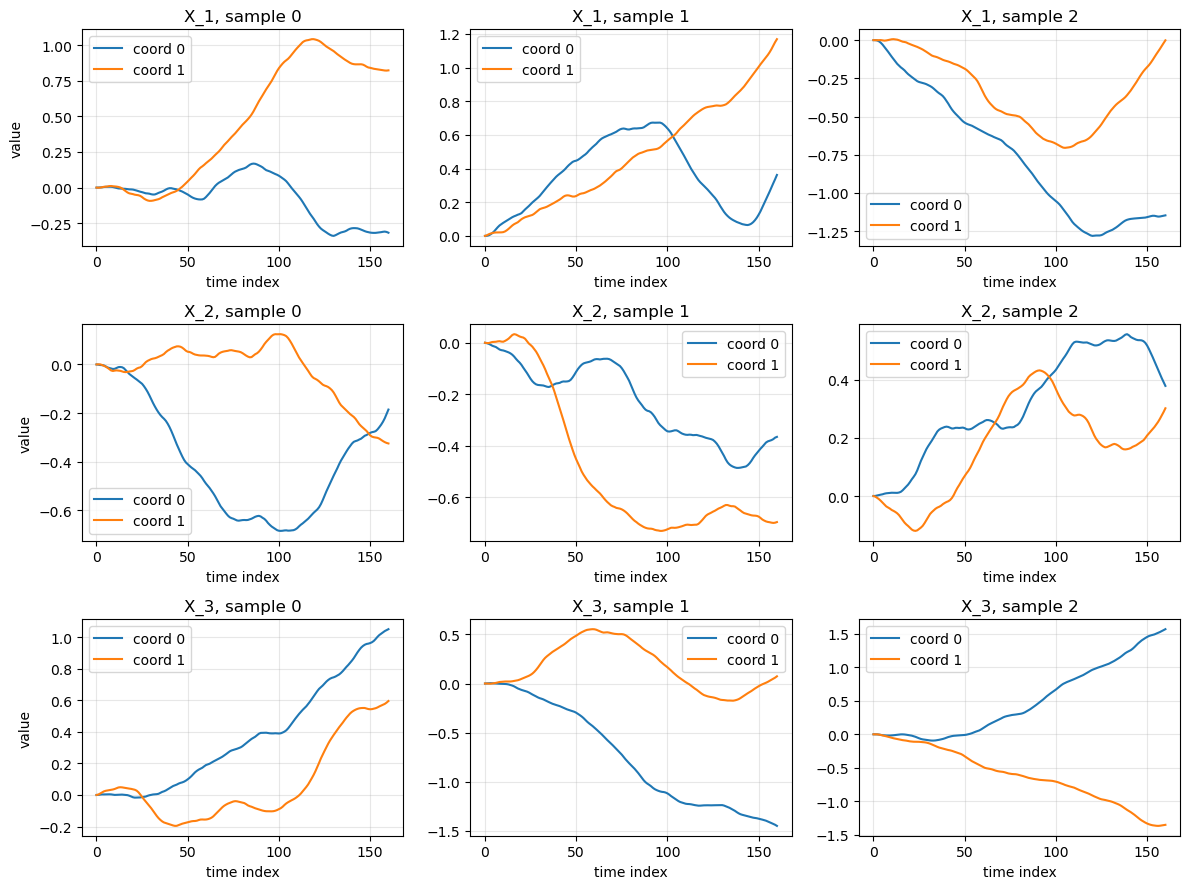

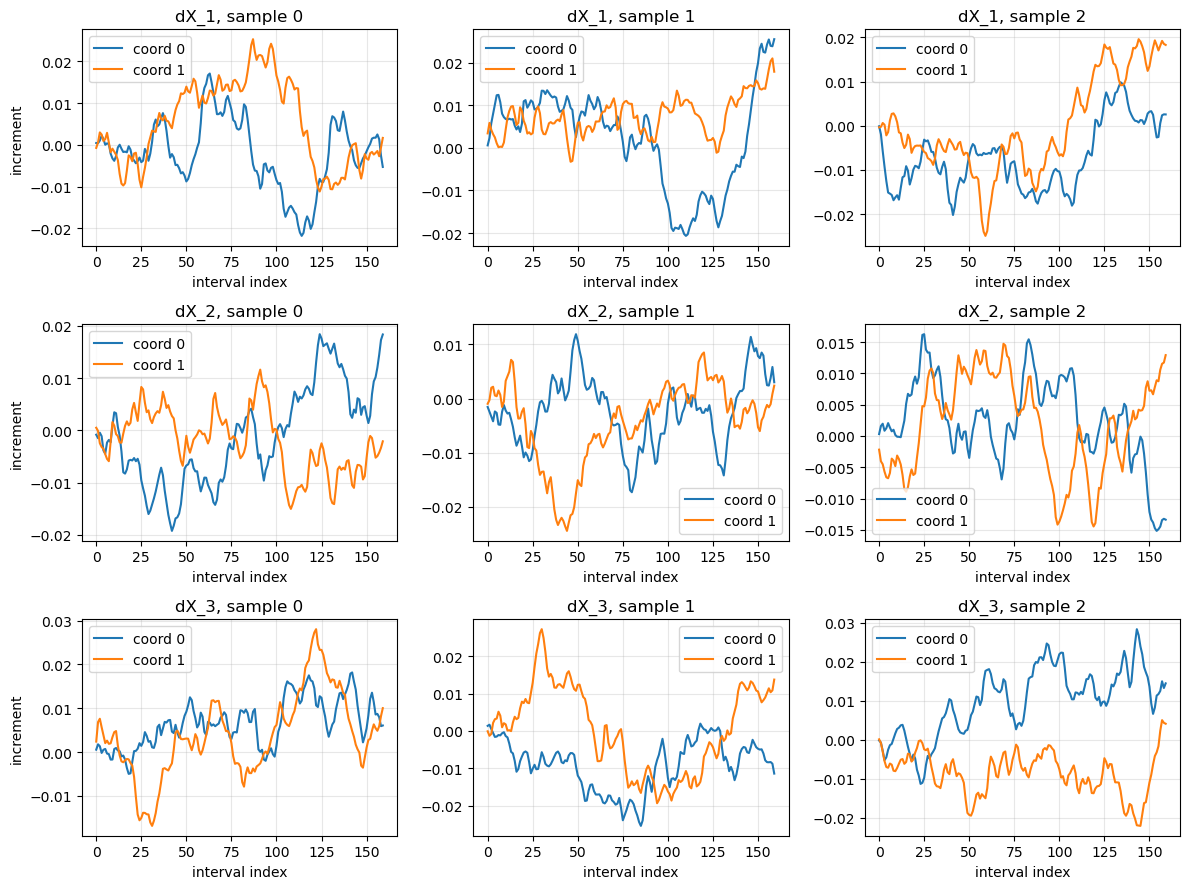

In [2]:



def plot_first_on_paths(
        X,
        *,
        max_samples=3,
        max_dims=3,
        title_prefix="X",
):
    """
    Plot a few sample paths from a DenseElemFirstOn path.

    Parameters
    ----------
    X : tuple
        DenseElemFirstOn path, with X[k].shape == (batch, steps + 1, dim**(k+1)).
    max_samples : int, default=3
        Number of batch samples to plot.
    max_dims : int, default=3
        Number of coordinates per level to plot.
    title_prefix : str, default="X"
        Prefix used in subplot titles.
    """
    X = tuple(jnp.asarray(level) for level in X)
    batch = X[0].shape[0]
    n_samples = min(batch, max_samples)

    n_levels = len(X)
    fig, axes = plt.subplots(
        n_levels,
        n_samples,
        figsize=(4 * n_samples, 3 * n_levels),
        squeeze=False,
    )

    for k, level in enumerate(X, start=1):
        coords = min(level.shape[-1], max_dims)
        t = jnp.arange(level.shape[1])

        for i in range(n_samples):
            ax = axes[k - 1, i]
            for c in range(coords):
                ax.plot(t, level[i, :, c], label=f"coord {c}")
            ax.set_title(f"{title_prefix}_{k}, sample {i}")
            ax.set_xlabel("time index")
            ax.grid(True, alpha=0.3)
            if i == 0:
                ax.set_ylabel("value")
            if coords <= 6:
                ax.legend()

    plt.tight_layout()
    plt.show()


def plot_first_on_increments(
        dX,
        *,
        max_samples=3,
        max_dims=3,
        title_prefix="dX",
):
    """
    Plot a few increment coordinates from a DenseElemFirstOn increment tuple.

    Parameters
    ----------
    dX : tuple
        Positive tensor levels interpreted as interval increments, with
        dX[k].shape == (batch, steps, dim**(k+1)).
    max_samples : int, default=3
        Number of batch samples to plot.
    max_dims : int, default=3
        Number of coordinates per level to plot.
    title_prefix : str, default="dX"
        Prefix used in subplot titles.
    """
    dX = tuple(jnp.asarray(level) for level in dX)
    batch = dX[0].shape[0]
    n_samples = min(batch, max_samples)

    n_levels = len(dX)
    fig, axes = plt.subplots(
        n_levels,
        n_samples,
        figsize=(4 * n_samples, 3 * n_levels),
        squeeze=False,
    )

    for k, level in enumerate(dX, start=1):
        coords = min(level.shape[-1], max_dims)
        t = jnp.arange(level.shape[1])

        for i in range(n_samples):
            ax = axes[k - 1, i]
            for c in range(coords):
                ax.plot(t, level[i, :, c], label=f"coord {c}")
            ax.set_title(f"{title_prefix}_{k}, sample {i}")
            ax.set_xlabel("interval index")
            ax.grid(True, alpha=0.3)
            if i == 0:
                ax.set_ylabel("increment")
            if coords <= 6:
                ax.legend()

    plt.tight_layout()
    plt.show()


plot_first_on_paths(X, max_samples=3, max_dims=2, title_prefix="X")
plot_first_on_increments(dX, max_samples=3, max_dims=2, title_prefix="dX")

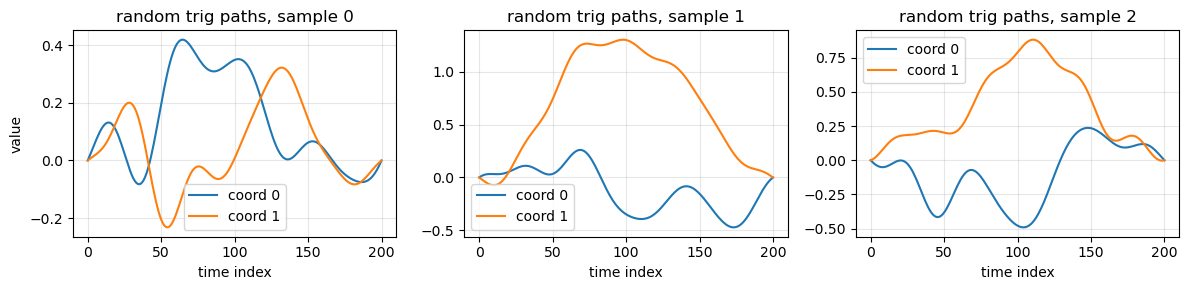

In [3]:
def plot_sample_paths(X, *, max_samples=3, max_dims=3, title_prefix="X"):
    X = np.asarray(X)
    n_samples = min(X.shape[0], max_samples)
    n_dims = min(X.shape[-1], max_dims)
    t = np.arange(X.shape[1])

    fig, axes = plt.subplots(1, n_samples, figsize=(4 * n_samples, 3), squeeze=False)

    for i in range(n_samples):
        ax = axes[0, i]
        for d in range(n_dims):
            ax.plot(t, X[i, :, d], label=f"coord {d}")
        ax.set_title(f"{title_prefix}, sample {i}")
        ax.set_xlabel("time index")
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.set_ylabel("value")
        ax.legend()

    plt.tight_layout()
    plt.show()


key = jr.PRNGKey(123)

X = random_trigonometric_polynomial_paths(
    key,
    batch=3,

    steps=200,
    dim=2,
    n_modes=6,
    scale=0.25,
    decay=1.5,
)

plot_sample_paths(X, max_samples=3, max_dims=2, title_prefix="random trig paths")

kind=integrated_ou, dim=2, trunc=2, decay=no_decay, lambda=1.0, factorial=False, seed=2148
X level shapes: [(2, 13, 2), (2, 13, 4)]
Y level shapes: [(3, 16, 2), (3, 16, 4)]


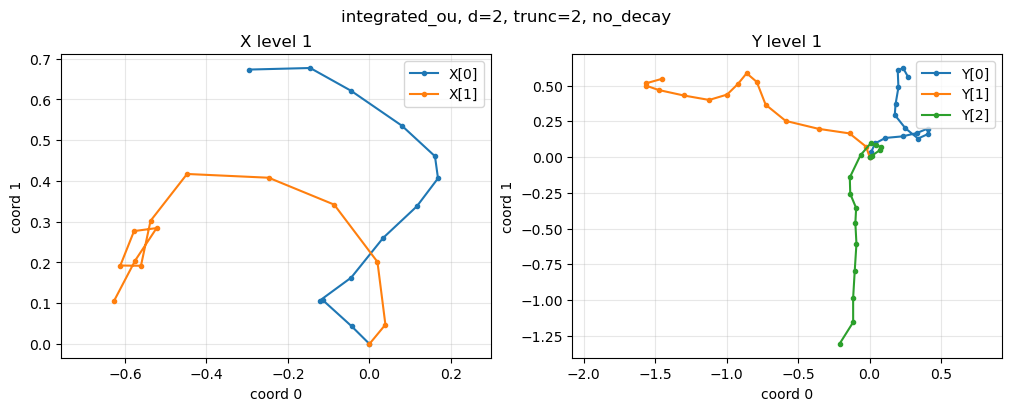

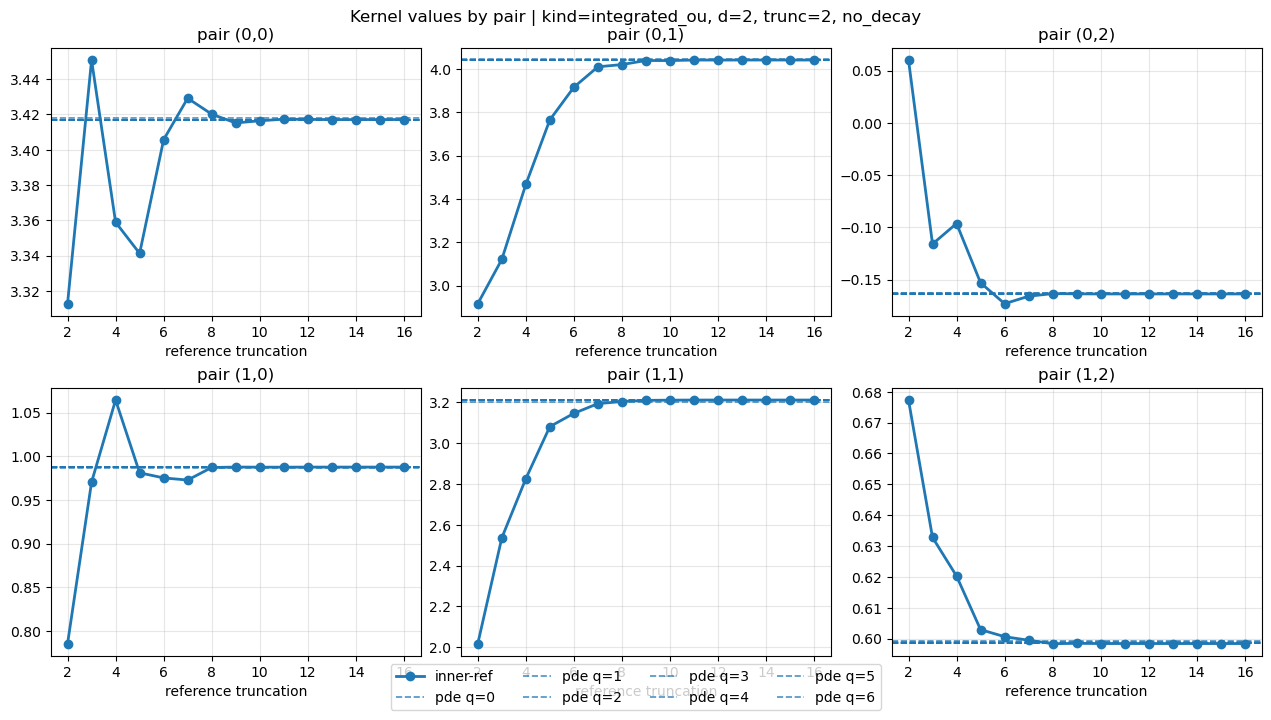

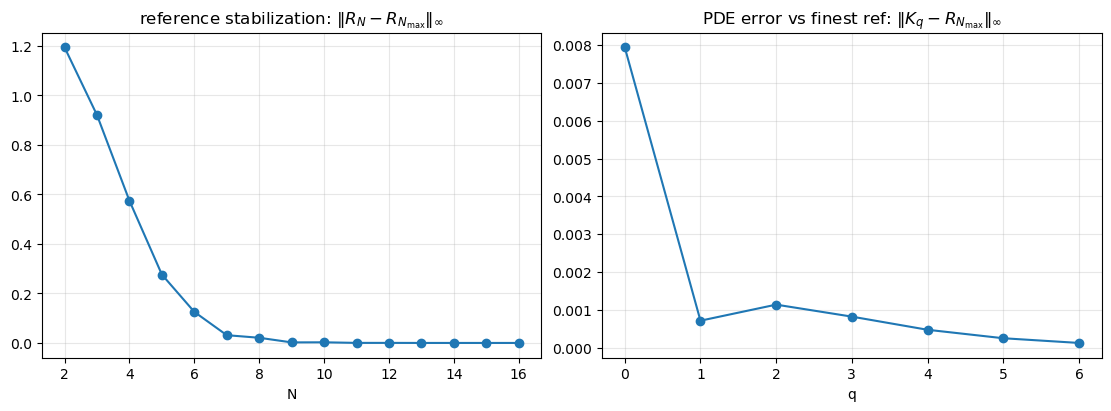


Worst-pair diagnostics against finest available reference:
  q=0: worst pair=(np.int64(1), np.int64(1)), pde= 3.20339285, ref= 3.21132828, abs_err= 0.00793543
  q=1: worst pair=(np.int64(1), np.int64(2)), pde= 0.59912744, ref= 0.59840787, abs_err= 0.00071956
  q=2: worst pair=(np.int64(0), np.int64(1)), pde= 4.04059200, ref= 4.04173544, abs_err= 0.00114344
  q=3: worst pair=(np.int64(0), np.int64(1)), pde= 4.04090866, ref= 4.04173544, abs_err= 0.00082678
  q=4: worst pair=(np.int64(0), np.int64(1)), pde= 4.04125577, ref= 4.04173544, abs_err= 0.00047967
  q=5: worst pair=(np.int64(0), np.int64(1)), pde= 4.04147898, ref= 4.04173544, abs_err= 0.00025646
  q=6: worst pair=(np.int64(0), np.int64(1)), pde= 4.04160333, ref= 4.04173544, abs_err= 0.00013211
kind=integrated_ou, dim=2, trunc=2, decay=geometric_decay, lambda=0.8, factorial=False, seed=2128
X level shapes: [(2, 13, 2), (2, 13, 4)]
Y level shapes: [(3, 16, 2), (3, 16, 4)]


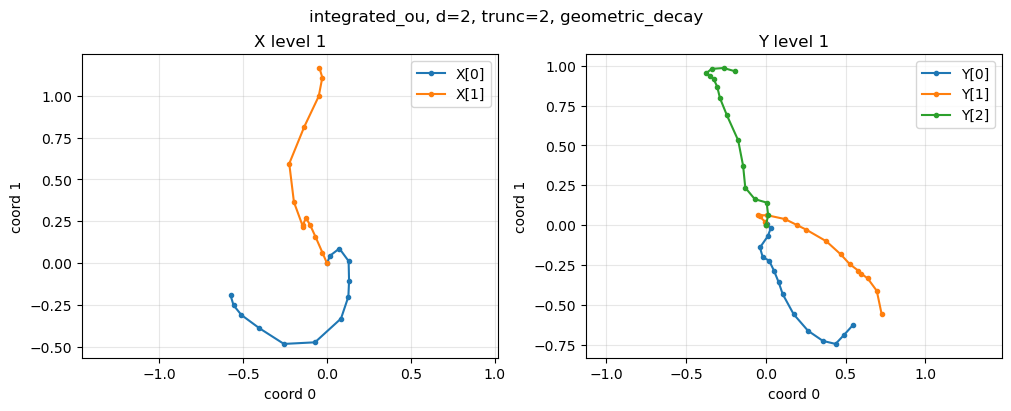

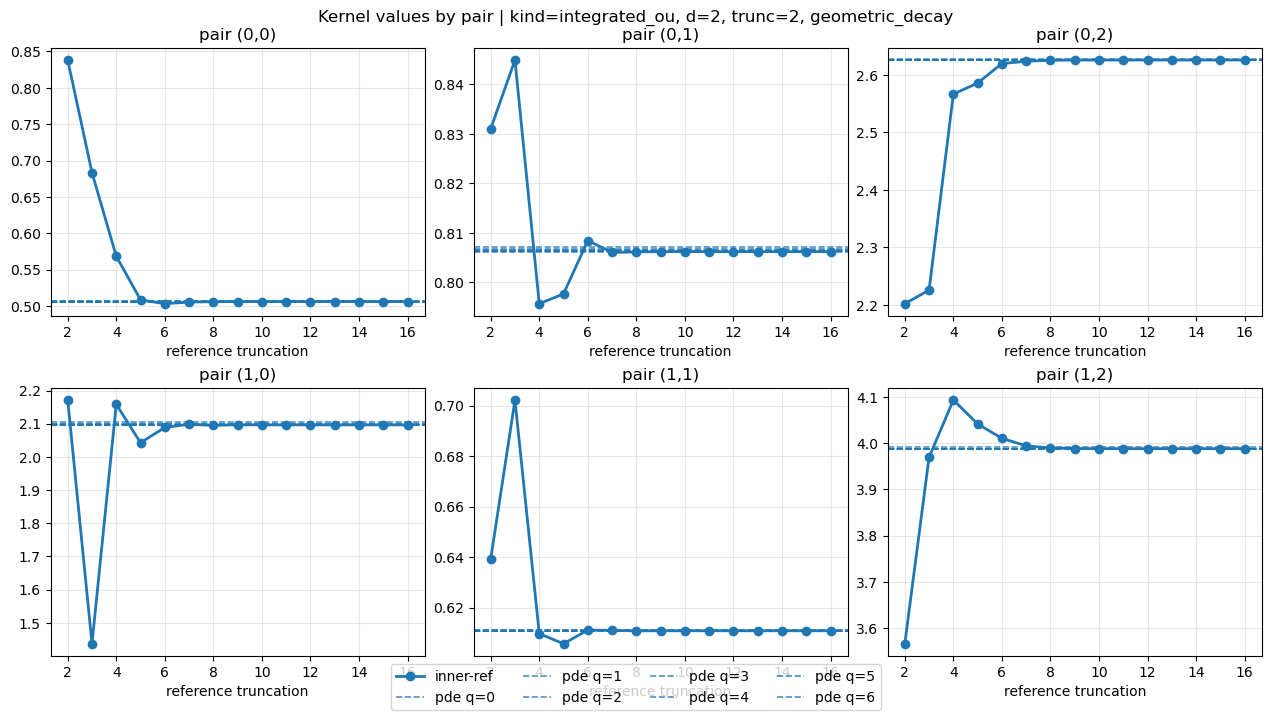

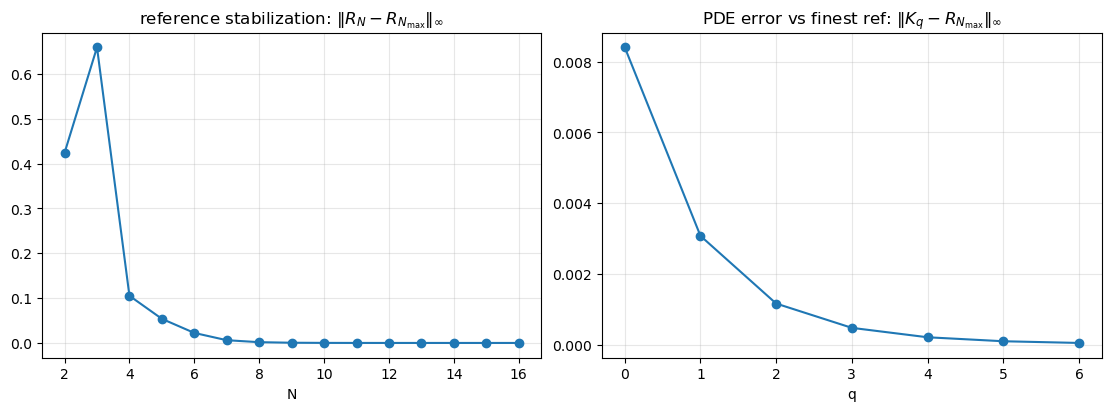


Worst-pair diagnostics against finest available reference:
  q=0: worst pair=(np.int64(1), np.int64(0)), pde= 2.10489943, ref= 2.09649427, abs_err= 0.00840516
  q=1: worst pair=(np.int64(1), np.int64(0)), pde= 2.09957073, ref= 2.09649427, abs_err= 0.00307646
  q=2: worst pair=(np.int64(1), np.int64(0)), pde= 2.09765776, ref= 2.09649427, abs_err= 0.00116349
  q=3: worst pair=(np.int64(1), np.int64(0)), pde= 2.09697090, ref= 2.09649427, abs_err= 0.00047663
  q=4: worst pair=(np.int64(1), np.int64(0)), pde= 2.09670488, ref= 2.09649427, abs_err= 0.00021061
  q=5: worst pair=(np.int64(1), np.int64(0)), pde= 2.09659247, ref= 2.09649427, abs_err= 0.00009820
  q=6: worst pair=(np.int64(1), np.int64(2)), pde= 3.98816046, ref= 3.98821062, abs_err= 0.00005015
kind=integrated_ou, dim=2, trunc=2, decay=factorial_decay, lambda=1.0, factorial=True, seed=3148
X level shapes: [(2, 13, 2), (2, 13, 4)]
Y level shapes: [(3, 16, 2), (3, 16, 4)]


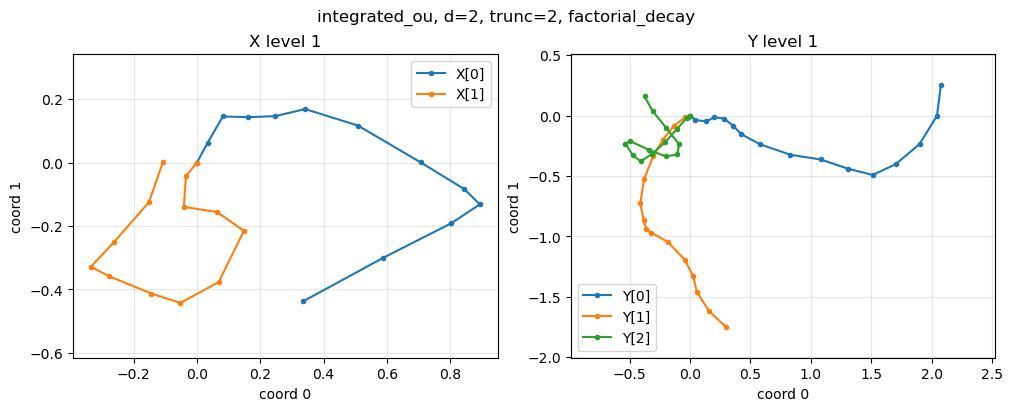

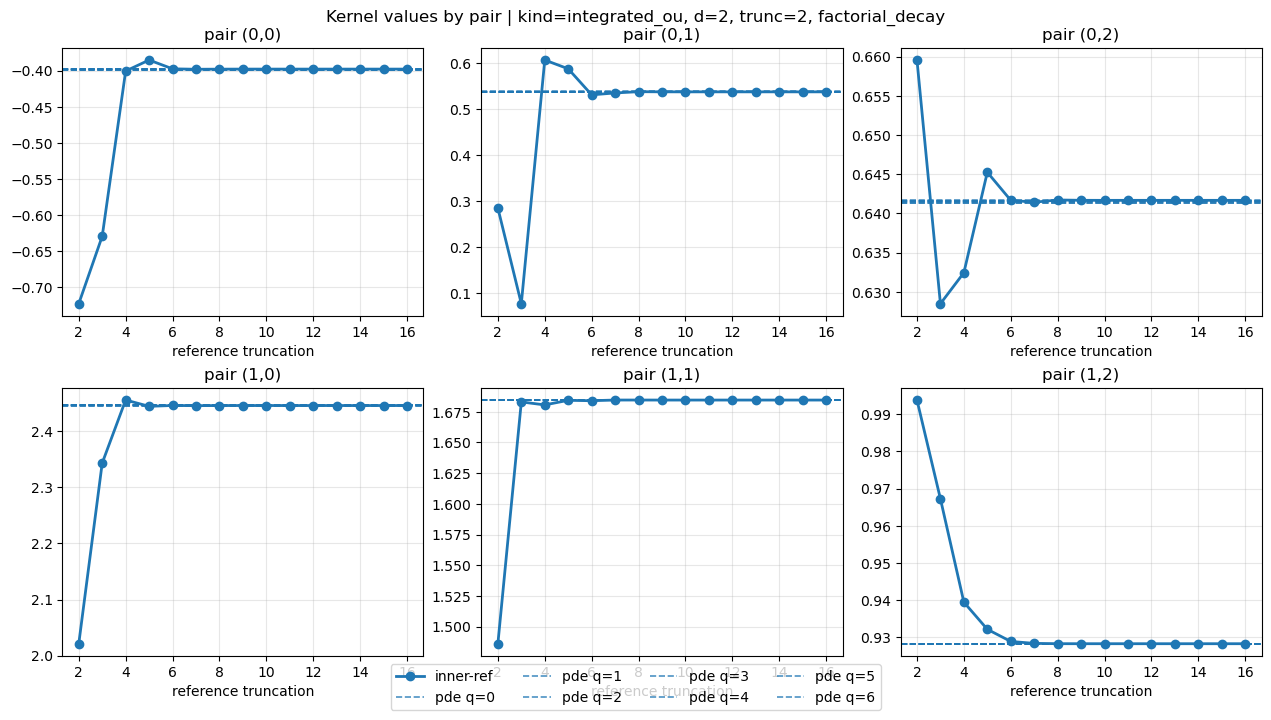

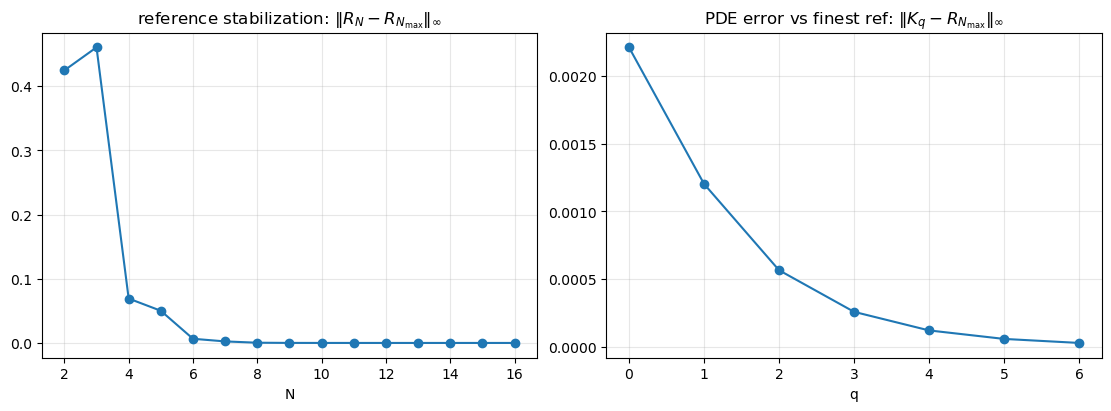


Worst-pair diagnostics against finest available reference:
  q=0: worst pair=(np.int64(0), np.int64(1)), pde= 0.53961985, ref= 0.53740907, abs_err= 0.00221079
  q=1: worst pair=(np.int64(0), np.int64(0)), pde=-0.39900733, ref=-0.39780464, abs_err= 0.00120269
  q=2: worst pair=(np.int64(0), np.int64(0)), pde=-0.39836996, ref=-0.39780464, abs_err= 0.00056532
  q=3: worst pair=(np.int64(0), np.int64(0)), pde=-0.39806267, ref=-0.39780464, abs_err= 0.00025803
  q=4: worst pair=(np.int64(0), np.int64(0)), pde=-0.39792555, ref=-0.39780464, abs_err= 0.00012091
  q=5: worst pair=(np.int64(0), np.int64(0)), pde=-0.39786282, ref=-0.39780464, abs_err= 0.00005818
  q=6: worst pair=(np.int64(0), np.int64(0)), pde=-0.39783313, ref=-0.39780464, abs_err= 0.00002849
kind=trig, dim=2, trunc=3, decay=no_decay, lambda=1.0, factorial=False, seed=2249
X level shapes: [(2, 13, 2), (2, 13, 4), (2, 13, 8)]
Y level shapes: [(3, 16, 2), (3, 16, 4), (3, 16, 8)]


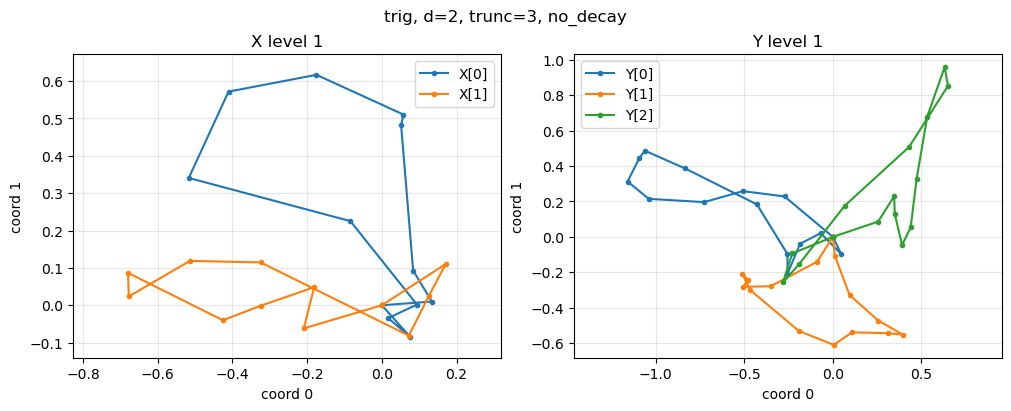

In [ ]:
from jax import config
config.update("jax_enable_x64", True)

import numpy as np
import matplotlib.pyplot as plt
import jax.random as jr

from tensordev import Jax
from tensordev.kernel.free import free_kernel
from random_paths import (
    integrated_ou_first_on_path,
    random_trigonometric_polynomial_paths_first_on,
    path_to_increments,
)

CORE = Jax()

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

BATCH_X = 2
BATCH_Y = 3
STEPS_X = 12
STEPS_Y = 15
MAX_REF_TRUNC = 16
Q_LIST = [0, 1, 2, 3, 4, 5, 6]

# Same qualitative family as your former test cases, but now as notebook diagnostics.
PATH_CASES = [
    dict(path_kind="integrated_ou", dim=2, trunc=2),
    #dict(path_kind="integrated_ou", dim=3, trunc=2),
    dict(path_kind="trig",          dim=2, trunc=3),
    dict(path_kind="trig",          dim=2, trunc=2),
    dict(path_kind="integrated_ou", dim=2, trunc=4),
    #dict(path_kind="integrated_ou", dim=3, trunc=1),
]

DECAY_CASES = [
    dict(name="no_decay",        level_lambda=1.0, factorial=False),
    dict(name="geometric_decay", level_lambda=0.8, factorial=False),
    dict(name="factorial_decay", level_lambda=1.0, factorial=True),
]

# If you want only a subset, replace ALL_CASES by a hand-picked list.
ALL_CASES = [
    {**pc, **dc, "seed": 2026 + 100 * (pc["path_kind"] == "trig") + 10 * pc["dim"] + pc["trunc"]
                        + 1000 * dc["factorial"] + int(100 * dc["level_lambda"])}
    for pc in PATH_CASES
    for dc in DECAY_CASES
]


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def _random_first_on_path(
    path_kind,
    key,
    *,
    batch,
    steps,
    dim,
    trunc,
    level_lambda,
    factorial,
):
    if path_kind == "integrated_ou":
        return integrated_ou_first_on_path(
            key,
            batch=batch,
            steps=steps,
            dim=dim,
            trunc=trunc,
            level_lambda=level_lambda,
            factorial=factorial,
        )

    if path_kind == "trig":
        return random_trigonometric_polynomial_paths_first_on(
            key,
            batch=batch,
            steps=steps,
            dim=dim,
            trunc=trunc,
            level_lambda=level_lambda,
            factorial=factorial,
        )

    raise ValueError(f"Unknown path_kind={path_kind!r}.")


def _broadcast_pairwise_levels(x, y):
    batch_x = x[0].shape[:-1]
    batch_y = y[0].shape[:-1]
    nx = len(batch_x)
    ny = len(batch_y)

    x = tuple(level.reshape(batch_x + (1,) * ny + level.shape[-1:]) for level in x)
    y = tuple(level.reshape((1,) * nx + batch_y + level.shape[-1:]) for level in y)
    return x, y


def _pairwise_inner_products(dev_x, dev_y):
    dev_x_bc, dev_y_bc = _broadcast_pairwise_levels(dev_x, dev_y)
    return np.asarray(CORE.tensor_inner_product(dev_x_bc, dev_y_bc))


def _reference_matrix(dx, dy, trunc_):
    dev_x = CORE.tensor_development(
        dx,
        axis=-2,
        trunc=trunc_,
        accumulate=False,
        output_starting_point=False,
        increment_input=True,
    )
    dev_y = CORE.tensor_development(
        dy,
        axis=-2,
        trunc=trunc_,
        accumulate=False,
        output_starting_point=False,
        increment_input=True,
    )
    return _pairwise_inner_products(dev_x, dev_y)


def _pde_matrix(dx, dy, q):
    return np.asarray(
        free_kernel(dx, dy, evaluate="terminal", return_fg=False, pairwise=True, backend="wavefront", dyadic_order=q,
                    increment_in=True)
    )


def _plot_level1_paths(X, Y, title):
    X1 = np.asarray(X[0])
    Y1 = np.asarray(Y[0])

    if X1.shape[-1] < 2 or Y1.shape[-1] < 2:
        print(f"{title}: skipping planar level-1 plot because dim < 2")
        return

    fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

    for i in range(X1.shape[0]):
        axes[0].plot(X1[i, :, 0], X1[i, :, 1], marker="o", ms=3, label=f"X[{i}]")
    axes[0].set_title("X level 1")
    axes[0].set_xlabel("coord 0")
    axes[0].set_ylabel("coord 1")
    axes[0].grid(True, alpha=0.3)
    axes[0].axis("equal")
    axes[0].legend()

    for j in range(Y1.shape[0]):
        axes[1].plot(Y1[j, :, 0], Y1[j, :, 1], marker="o", ms=3, label=f"Y[{j}]")
    axes[1].set_title("Y level 1")
    axes[1].set_xlabel("coord 0")
    axes[1].set_ylabel("coord 1")
    axes[1].grid(True, alpha=0.3)
    axes[1].axis("equal")
    axes[1].legend()

    fig.suptitle(title)
    plt.show()


def analyze_case(cfg, *, plot_paths=True, print_matrices=True):
    print("=" * 100)
    print(
        f"kind={cfg['path_kind']}, dim={cfg['dim']}, trunc={cfg['trunc']}, "
        f"decay={cfg['name']}, lambda={cfg['level_lambda']}, factorial={cfg['factorial']}, "
        f"seed={cfg['seed']}"
    )

    key = jr.PRNGKey(cfg["seed"])

    X = _random_first_on_path(
        cfg["path_kind"],
        key,
        batch=BATCH_X,
        steps=STEPS_X,
        dim=cfg["dim"],
        trunc=cfg["trunc"],
        level_lambda=cfg["level_lambda"],
        factorial=cfg["factorial"],
    )
    Y = _random_first_on_path(
        cfg["path_kind"],
        jr.fold_in(key, 1),
        batch=BATCH_Y,
        steps=STEPS_Y,
        dim=cfg["dim"],
        trunc=cfg["trunc"],
        level_lambda=cfg["level_lambda"],
        factorial=cfg["factorial"],
    )

    print("X level shapes:", [tuple(x.shape) for x in X])
    print("Y level shapes:", [tuple(y.shape) for y in Y])

    if plot_paths:
        _plot_level1_paths(
            X, Y,
            title=(
                f"{cfg['path_kind']}, d={cfg['dim']}, trunc={cfg['trunc']}, "
                f"{cfg['name']}"
            ),
        )

    dx = path_to_increments(X)
    dy = path_to_increments(Y)

    ref_ns = list(range(cfg["trunc"], MAX_REF_TRUNC + 1))
    refs = {N: _reference_matrix(dx, dy, trunc_=N) for N in ref_ns}
    pdes = {q: _pde_matrix(dx, dy, q=q) for q in Q_LIST}

    if print_matrices:
        for N in ref_ns:
            print(f"\nreference trunc + {N - cfg['trunc']} shape={refs[N].shape}")
            print(np.array2string(refs[N], precision=6, suppress_small=False, floatmode="maxprec_equal"))
        for q in Q_LIST:
            print(f"\npde n={q} shape={pdes[q].shape}")
            print(np.array2string(pdes[q], precision=6, suppress_small=False, floatmode="maxprec_equal"))

    # --------------------------------------------------------
    # Plot pairwise values: ref vs truncation, PDE vs n
    # --------------------------------------------------------
    fig, axes = plt.subplots(BATCH_X, BATCH_Y, figsize=(4.2 * BATCH_Y, 3.4 * BATCH_X), squeeze=False, constrained_layout=True)

    for i in range(BATCH_X):
        for j in range(BATCH_Y):
            ax = axes[i, j]

            ref_vals = [refs[N][i, j] for N in ref_ns]
            ax.plot(ref_ns, ref_vals, marker="o", linewidth=2, label="inner-ref")

            for q in Q_LIST:
                ax.axhline(
                    pdes[q][i, j],
                    linestyle="--",
                    linewidth=1.2,
                    alpha=0.8,
                    label=f"pde n={q}" if (i == 0 and j == 0) else None,
                )

            ax.set_title(f"pair ({i},{j})")
            ax.set_xlabel("reference truncation")
            ax.grid(True, alpha=0.3)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.suptitle(
        f"Kernel values by pair | kind={cfg['path_kind']}, d={cfg['dim']}, "
        f"trunc={cfg['trunc']}, {cfg['name']}",
        y=1.02,
    )

    if handles:
        fig.legend(
            handles,
            labels,
            loc="lower center",
            bbox_to_anchor=(0.5, -0.02),
            ncol=min(len(labels), 4),
            frameon=True,
        )

    plt.show()

    # --------------------------------------------------------
    # Plot max error to finest available reference
    # --------------------------------------------------------
    ref_finest = refs[ref_ns[-1]]
    q_errors = [float(np.max(np.abs(pdes[q] - ref_finest))) for q in Q_LIST]
    ref_tail = [
        float(np.max(np.abs(refs[N] - ref_finest)))
        for N in ref_ns
    ]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

    axes[0].plot(ref_ns, ref_tail, marker="o")
    axes[0].set_title(r"reference stabilization: $\|R_N - R_{N_{\max}}\|_\infty$")
    axes[0].set_xlabel("N")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(Q_LIST, q_errors, marker="o")
    axes[1].set_title(r"PDE error vs finest ref: $\|K_q - R_{N_{\max}}\|_\infty$")
    axes[1].set_xlabel("n")
    axes[1].grid(True, alpha=0.3)

    plt.show()

    # --------------------------------------------------------
    # Print worst pair per n against finest reference
    # --------------------------------------------------------
    print("\nWorst-pair diagnostics against finest available reference:")
    for q in Q_LIST:
        err = np.abs(pdes[q] - ref_finest)
        ij = np.unravel_index(np.argmax(err), err.shape)
        print(
            f"  n={q}: worst pair={ij}, "
            f"pde={pdes[q][ij]: .8f}, ref={ref_finest[ij]: .8f}, "
            f"abs_err={err[ij]: .8f}"
        )

    return {
        "cfg": cfg,
        "X": X,
        "Y": Y,
        "dx": dx,
        "dy": dy,
        "refs": refs,
        "pdes": pdes,
        "ref_ns": ref_ns,
    }


# ------------------------------------------------------------
# Run all cases
# ------------------------------------------------------------

results = []
for cfg in ALL_CASES:
    results.append(analyze_case(cfg, plot_paths=True, print_matrices=False))